# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [3]:
plans.head()

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [4]:
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [5]:
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [6]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [7]:
# inspección de users con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [8]:
# inspección de plans con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [9]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [10]:
# cantidad de nulos para users
print(users.isna().sum())
print()
print(users.isna().mean() * 100)

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64

user_id        0.000
first_name     0.000
last_name      0.000
age            0.000
city          11.725
reg_date       0.000
plan           0.000
churn_date    88.350
dtype: float64


In [11]:
# cantidad de nulos para usage
print(usage.isna().sum())
print()
print(usage.isna().mean() * 100)

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64

id           0.000
user_id      0.000
type         0.000
date         0.125
duration    55.190
length      44.740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
Se evidencian valores nulos en las columnas duration, length, date, city y churn_date.
Con unas proporciones de 55.2% (duration), 44.7%(length), 0.13% (date), 11.7% (city) y 88.4%(churn_date)
- Indica qué harías: ¿imputar, eliminar, ignorar?   

* churn_date: Se conservan los nulos sin modificar, ya que representan clientes activos que no han cancelado el servicio.   
* city: Se investigará para imputar por la moda o reemplazar los valores nulos por 'Unknown'.   
* date: Al representar solo el 0.125% de los datos (< 5%), se pueden eliminar las filas con nulos o ignorar sin alterar la muestra.   
* duration y length: Se conservan como nulos, ya que son nulos estructurales causados por la columna `type`: los mensajes no generan `duration` y las llamadas no generan `length`. No deben imputarse con medias ni modelos.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [12]:
# explorar columnas numéricas de users
#uso el medoto select_dtypes con el fin de seleccionar de forma dinamica solo las columnas que tengan un tipo numerico 
numericas_user = users.select_dtypes(include=['number'])
print(numericas_user.describe())
print()
print('Sentinels: ',(users['age'] == -999).sum())

            user_id          age
count   4000.000000  4000.000000
mean   11999.500000    33.739750
std     1154.844867   123.232257
min    10000.000000  -999.000000
25%    10999.750000    32.000000
50%    11999.500000    47.000000
75%    12999.250000    63.000000
max    13999.000000    79.000000

Sentinels:  55


- La columna `user_id` tiene una desviacion estandar baja, pero al ser un identificador del usuario (id) no debe interpretarse de forma estadistica  
- La columna `age` tiene una desviacion estandar muy alta, se evidecia la presencia de un sentinel `-999` como valor minimo


In [13]:
columnas_users = ['city','plan']
print('Resumen estadistico')
print(users[columnas_users].describe())
print() #salto de linea
print('Frecuencia absoluta por ciudad')
print(users['city'].value_counts())

Resumen estadistico
          city    plan
count     3531    4000
unique       7       2
top     Bogotá  Basico
freq       808    2595

Frecuencia absoluta por ciudad
Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64


- En la columna `city` se evidencian valores nulos y el uso del sentinel `?` para un total de 565 registros sin una ciudad válida especificada. La moda es Bogotá y representa el 20.2% de los registros.
- En la columna `plan` no se evidencian valores nulos o sentinels. La moda es Basico y representa el 64.88% de los registros.

In [14]:
# explorar columnas numéricas de usage
numericas_usage = usage.select_dtypes(include=['number'])
print(numericas_usage.describe())
print()
#validamos los valores nulos 
print('Cantidad de nulos en duration: ', usage['duration'].isna().sum())
print('Cantidad de nulos en length: ',usage['length'].isna().sum())

#el coeficiente de variacion se calcula dividiendo la desviacion estandar(std) sobre la media(mean)
#el coeficiente de variacion nos ayuda a saber que tan dispersos estan los datos
print('Coeficiente de variacion para duration: ', (usage['duration'].std()/usage['duration'].mean())*100)
print('Coeficiente de variacion para lenght ', (usage['length'].std()/usage['length'].mean())*100)


                id       user_id      duration        length
count  40000.00000  40000.000000  17924.000000  22104.000000
mean   20000.50000  12002.405975      5.202237     52.127398
std    11547.14972   1157.279564      6.842701     56.611183
min        1.00000  10000.000000      0.000000      0.000000
25%    10000.75000  10996.000000      1.437500     37.000000
50%    20000.50000  12013.000000      3.500000     50.000000
75%    30000.25000  13005.000000      6.990000     64.000000
max    40000.00000  13999.000000    120.000000   1490.000000

Cantidad de nulos en duration:  22076
Cantidad de nulos en length:  17896
Coeficiente de variacion para duration:  131.5338187426795
Coeficiente de variacion para lenght  108.60158984668038


**Variables Identificadoras:** 
   - Las columnas `id` y `user_id` corresponden a identificadores únicos y claves de usuario, por lo que **se excluyen del análisis estadístico descriptivo**.

2. **Calidad de los Datos (Valores Faltantes):**
   - **`duration`:** Presenta **22,076 valores nulos**, lo que representa un **55.19%** del total de los registros (40,000).
   - **`length`:** Presenta **17,896 valores nulos**, equivalente al **44.74%** del dataset.
   - *Nota:* Ambas columnas sufren una pérdida considerable de información, por lo que será necesario definir una estrategia de imputación o filtrado antes de avanzar al modelado o análisis posterior.

3. **Dispersión, Asimetría y Valores Atípicos (*Outliers*):**
   - **`duration`:** Posee un **Coeficiente de Variación del 131.5%**, lo que indica una variabilidad extrema. La media ($5.20$) se encuentra inflada con respecto a la mediana ($3.50$), y existe una brecha notable entre el percentil 75% ($6.99$) y el valor máximo ($120.00$), confirmando presencia de *outliers* sesgados a la derecha.
   - **`length`:** Muestra un **Coeficiente de Variación del 108.6%**, reflejando alta heterogeneidad en los datos. Aunque la mediana ($50.00$) y el percentil 50% coinciden adecuadamente, existe un valor máximo atípico de $1490.00$ (frente a un percentil 75% de $64.00$).

In [15]:
usage['type'].describe()

count     40000
unique        2
top        text
freq      22092
Name: type, dtype: object

- La columna `type`, en esta columna no se evidencian valores nulos ni sentinels, la moda es `text` y reprensenta el 55.23% de los registros

---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?

en la columna city se usa el sentinel `?` y en age se usa `-999`
- ¿Qué acción tomarías?

Buscaria remplazar los sentiles por valores nulos o con la mediana para el caso de age

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [16]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'] , errors='coerce', utc=True)

In [17]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce',utc=True)

In [18]:
# Revisar los años presentes en `reg_date` de users
print((users['reg_date'].dt.year).value_counts())

2024    1330
2023    1316
2022    1314
2026      40
Name: reg_date, dtype: int64


En `reg_date`, en este caso estamos haciendo un analisis sobre datos registrados hasta el año 2024   
y en la columna `reg_date` se observan 40 registros con el año 2026

In [19]:
# Revisar los años presentes en `date` de usage
print((usage['date'].dt.year).value_counts())

2024.0    39950
Name: date, dtype: int64


En `date`, en la columna date todos los registros comparten el mismo año 2024 pero hay 50 valores nulos.   
Basaremos el análisis en estas fechas.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
En la columna `reg_date` de users aparecieron 40 registros con el año 2026 un año no trasncurrido al momento de guardar los datos.
- ¿Qué harías con ellas?   
Para `reg_date` buscaria remplazar las 40 registros del año 2026 por nulos.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [20]:
# Reemplazar -999 por la mediana de age
#aseguramos que la columna sea de un tipo numerico
users['age'] = pd.to_numeric(users['age'], errors='coerce').astype('Int64')
users['age'] = users['age'].replace(-999,pd.NA)
age_mediana = users['age'].median()
users['age'] = users['age'].fillna(age_mediana)

# Verificar cambios
#validamos que no queden registros con el valor -999
print((users['age'] == -999).sum())

0


In [21]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)

# Verificar cambios
#validamos que no queden registros con el valor '?'
print((users['city'] == '?').sum())
#validamos el nuevo porcentaje de nulos despues de remplazar el sentinel '?'
print('Porcentaje de nulos en city: ',users['city'].isna().mean()*100)

0
Porcentaje de nulos en city:  14.124999999999998


In [22]:
# Marcar fechas futuras como NA para reg_date
# nos aseguramos de que la columna sea tipo fecha
users['reg_date'] = pd.to_datetime(users['reg_date'])
#uso pd.NaT en lugar de pd.NA para que la columna conserve su tipo de dato como fecha
users.loc[users['reg_date'].dt.year > 2024] = pd.NaT 
# Verificar cambios
#validamos que no quedan registros con este año
(users['reg_date'].dt.year == 2026).sum() 

0

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [23]:
# Verificación MAR en usage (Missing At Random) para duration
usage['duration'].isna().groupby(usage['type']).mean()

type
call    0.000000
text    0.999276
Name: duration, dtype: float64

In [24]:
# Verificación MAR en usage (Missing At Random) para length
usage['length'].isna().groupby(usage['type']).mean()

type
call    0.99933
text    0.00000
Name: length, dtype: float64

Los valores nulos en `duration` y `length` son mutuamente excluyentes y dependen directamente de la columna `type`, por lo que se confirma que son faltantes de tipo `MAR`.   
Si `type` es `text` (un mensaje de texto) no tiene sentido registrar una duración, pero sí una longitud; y ocurre exactamente lo contrario cuando `type` es `call` (una llamada).   
Como esta interacción hace parte importante de la lógica estructural se decide dejar los valores como nulos para no alterar ni distorsionar el análisis.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [25]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby('user_id')[['is_text','is_call','duration']].sum().reset_index()

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [26]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={
    'is_text': 'cant_mensajes',
    'is_call': 'cant_llamadas',
    'duration': 'cant_minutos_llamada'
})

# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [27]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = pd.merge(users, usage_agg, on='user_id', how='left')
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00+00:00,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53,<NA>,2022-01-01 06:34:17.914478619+00:00,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239+00:00,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858+00:00,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478+00:00,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [28]:
# Resumen estadístico de las columnas numéricas
user_profile.describe()

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3960.000000,3959.000000,3959.000000,3959.000000
mean,48.119444,5.525385,4.483708,23.331074
std,17.686962,2.359503,2.143459,18.199917
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,48.000000,5.000000,4.000000,19.790000
75%,63.000000,7.000000,6.000000,31.405000
max,79.000000,17.000000,15.000000,155.690000


In [29]:
# Distribución porcentual del tipo de plan
user_profile['plan'].value_counts(normalize=True)

Basico     0.649747
Premium    0.350253
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

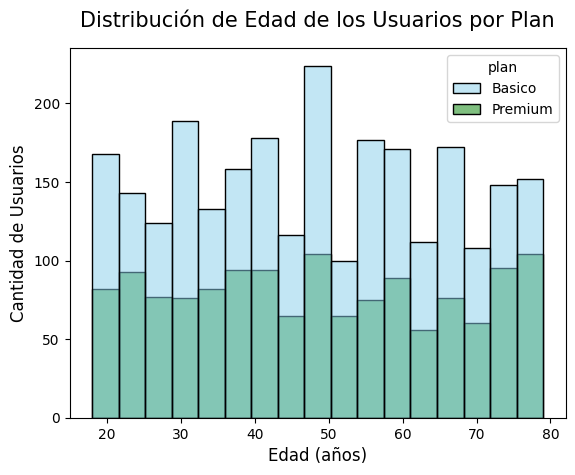

In [30]:

# Histograma para visualizar la edad (age)
sns.histplot(data=user_profile, x='age', hue='plan', palette=['skyblue', 'green'])
plt.title('Distribución de Edad de los Usuarios por Plan', fontsize=15, pad=15)
plt.xlabel('Edad (años)', fontsize=12)
plt.ylabel('Cantidad de Usuarios', fontsize=12)
plt.show()


💡Insights: 
- El plan Básico domina de manera constante la base de clientes en todas las edades, registrando entre $100$ y $200$ usuarios por grupo con un volumen máximo que supera los $200$ usuarios cerca de los 50 años.
- El plan Premium exhibe un comportamiento de contratación estable y homogéneo, oscilando entre los $50$ y $100$ usuarios en todas las edades.

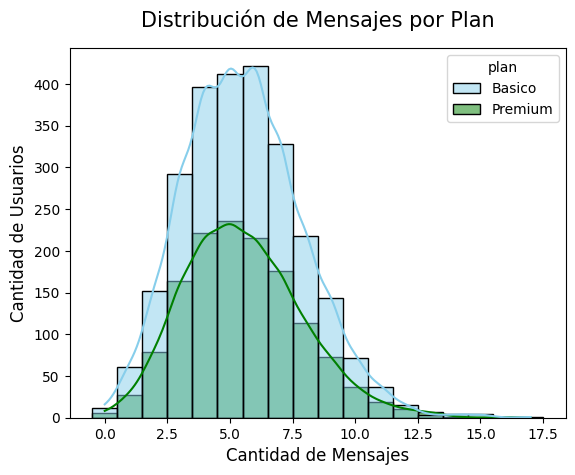

In [31]:
# Histograma para visualizar la cant_mensajes
#uso los parametros discrete=True y kde=True para mejorar la visualizacion del histograma
sns.histplot(data=user_profile, x='cant_mensajes', hue='plan', palette=['skyblue', 'green'], discrete=True, kde=True)
plt.title('Distribución de Mensajes por Plan', fontsize=15, pad=15)
plt.xlabel('Cantidad de Mensajes', fontsize=12)
plt.ylabel('Cantidad de Usuarios', fontsize=12)
plt.show()


💡Insights: 
- La distribución de la cantidad de mensajes muestra un claro sesgo a la derecha en ambos planes, con el punto mas alto concentrado entre los 5 y 6 mensajes. A partir de este rango, el volumen de usuarios decrece progresivamente hacia la derecha, alcanzando un límite máximo cercano a los 17 mensajes.

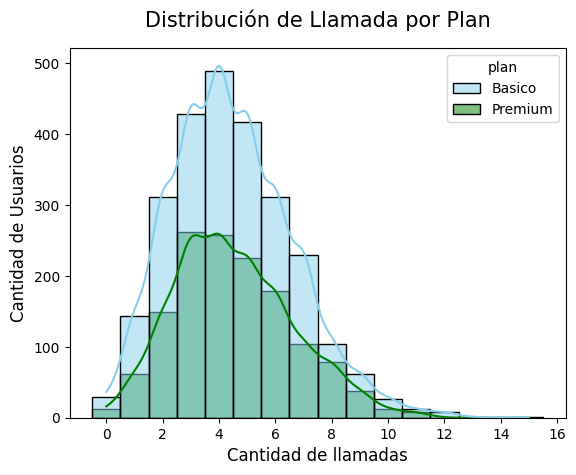

In [32]:
# Histograma para visualizar la cant_llamadas
#uso los parametros discrete=True y kde=True para mejorar la visualizacion del histograma
sns.histplot(data=user_profile, x='cant_llamadas', hue='plan', palette=['skyblue', 'green'],discrete=True,  kde=True)
plt.title('Distribución de Llamada por Plan', fontsize=15, pad=15)
plt.xlabel('Cantidad de llamadas', fontsize=12)
plt.ylabel('Cantidad de Usuarios', fontsize=12)
plt.show()


💡Insights: 
- Distribución homogénea entre ambos planes con sesgo a la derecha y mayor concentración cerca de las 4 llamadas.

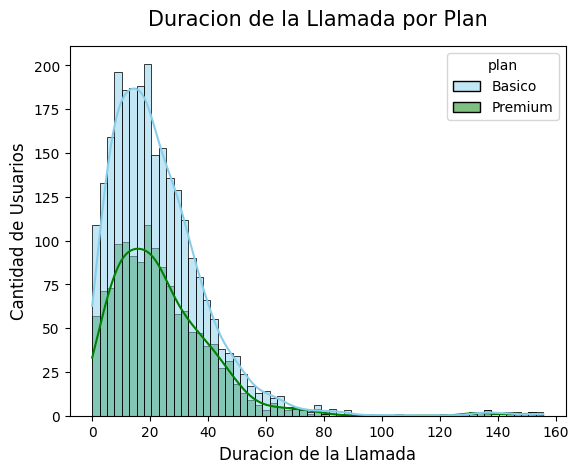

In [33]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data=user_profile, x='cant_minutos_llamada', hue='plan', palette=['skyblue', 'green'],  kde=True)

plt.title('Duracion de la Llamada por Plan', fontsize=15, pad=15)
plt.xlabel('Duracion de la Llamada', fontsize=12)
plt.ylabel('Cantidad de Usuarios', fontsize=12)

plt.show()

💡Insights: 
- La duración de las llamadas presenta una marcada asimetría positiva (sesgo a la derecha) en ambos planes. La mayor concentración de usuarios y el pico máximo se ubican entre los 12 y 20 minutos de duración.
- A partir de los 40 minutos la frecuencia decrece de forma sostenida, extendiéndose una cola larga con valores atípicos que alcanzan hasta los 160 minutos.
- El comportamiento entre los planes Básico y Premium mantiene una distribución homogénea en su tendencia central.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

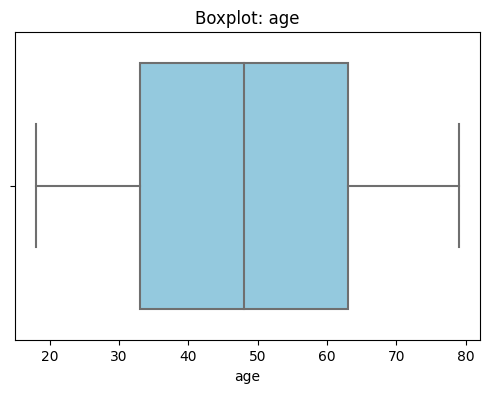

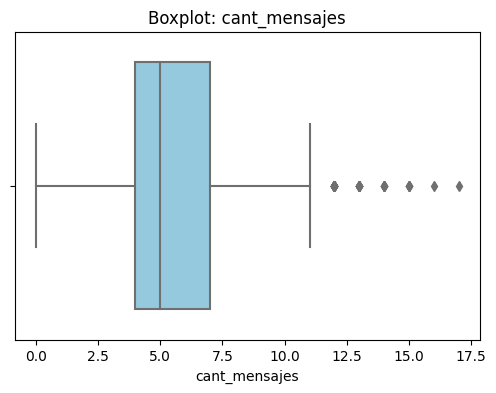

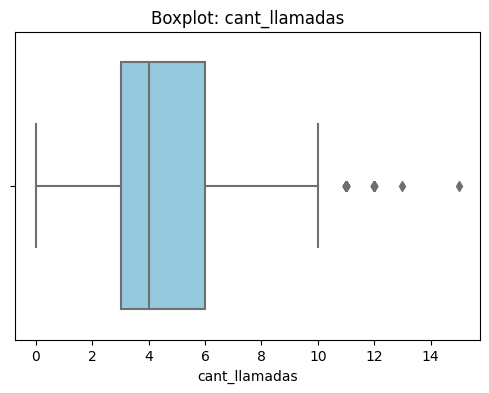

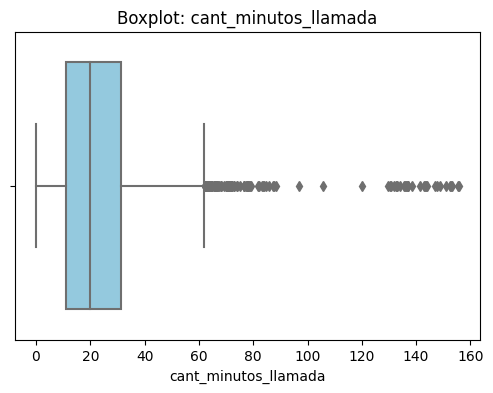

In [34]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    plt.figure(figsize=(6,4))
    sns.boxplot(data=user_profile, x=col, color='skyblue')
    plt.title(f'Boxplot: {col}')
    plt.show()

💡Insights: 
- Age: no observa la presencia de outliers
- cant_mensajes: outliers al lado derecho
- cant_llamadas: outliers al lado derecho
- cant_minutos_llamada: gran presencia de outliers al lado derecho

In [35]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1
    limite_superior = Q3 + 1.5 * IQR
    outliers_superiores = user_profile[user_profile[col] > limite_superior].shape[0]
    
    print(f"{col}")
    print(f"  Q1: {Q1:.2f}")
    print(f"  Q3: {Q3:.2f}")
    print(f"  IQR: {IQR:.2f}")
    print(f"  Cantidad de outliers superiores: {outliers_superiores}\n")

cant_mensajes
  Q1: 4.00
  Q3: 7.00
  IQR: 3.00
  Cantidad de outliers superiores: 46

cant_llamadas
  Q1: 3.00
  Q3: 6.00
  IQR: 3.00
  Cantidad de outliers superiores: 30

cant_minutos_llamada
  Q1: 11.12
  Q3: 31.41
  IQR: 20.29
  Cantidad de outliers superiores: 109



In [36]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3959.000000,3959.000000,3959.000000
mean,5.525385,4.483708,23.331074
std,2.359503,2.143459,18.199917
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.790000
75%,7.000000,6.000000,31.405000
max,17.000000,15.000000,155.690000


💡Insights: 
- cant_mensajes: mantener o no outliers, porqué?   
Se mantienen. Los valores atípicos (máximo de $17$ mensajes) representan consumos reales. Además, el impacto en las métricas centrales es mínimo, manteniendo una media ($5.52$) y mediana ($5.00$) prácticamente alineadas.
- cant_llamadas: mantener o no outliers, porqué?    
 Se mantienen. El valor máximo registrado es de $15$ llamadas. Al tratarse de eventos reales de uso del servicio sin errores de registro, deben conservarse para no sesgar la muestra de clientes.
- cant_minutos_llamada: mantener o no outliers, porqué?    
Se mantienen. Aunque el valor máximo alcanza los $155.69$ minutos (generando una cola más larga y elevando la media a $23.33$ vs. una mediana de $19.79$), estos datos reflejan patrones reales de usuarios vip

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [37]:
# Crear columna grupo_uso

def classify_segment(row):
    llamadas=row['cant_llamadas']
    mensajes=row['cant_mensajes']
    if llamadas < 5 and mensajes < 5:
        return 'Bajo uso'
    elif llamadas < 10 and mensajes < 10:
        return 'Uso medio'
    else:
        return 'Alto uso'

user_profile['grupo_uso'] = user_profile.apply(classify_segment, axis=1)
#con esta linea validamos la distribucion de la nueva columna
print(user_profile['grupo_uso'].value_counts()) 

Uso medio    2917
Bajo uso      766
Alto uso      317
Name: grupo_uso, dtype: int64


In [38]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00+00:00,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53,<NA>,2022-01-01 06:34:17.914478619+00:00,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239+00:00,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858+00:00,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478+00:00,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [39]:
# Crear columna grupo_edad
def classify_segment_by_age(row):
    age = row['age']
    #con esta linea manejamos los valores nulos
    if pd.isna(age):
        return None
        
    if age < 30:
        return 'Joven'
    elif age < 60:
        return 'Adulto'
    else:
        return 'Adulto Mayor'

user_profile['grupo_edad'] = user_profile.apply(classify_segment_by_age, axis=1)
# Verificar la distribución por grupo de edad
print(user_profile['grupo_edad'].value_counts())   

Adulto          2000
Adulto Mayor    1209
Joven            751
Name: grupo_edad, dtype: int64


In [40]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00+00:00,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53,<NA>,2022-01-01 06:34:17.914478619+00:00,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239+00:00,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858+00:00,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478+00:00,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

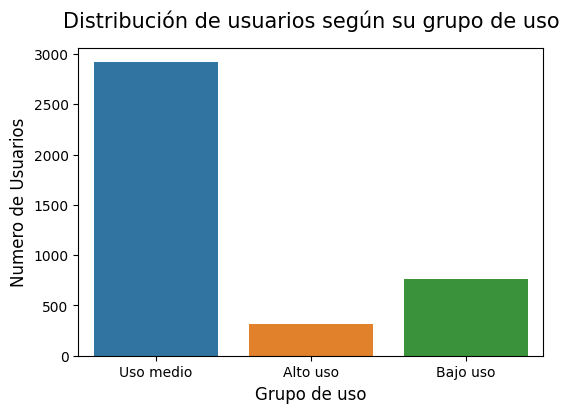

In [41]:
# Visualización de los segmentos por uso
plt.figure(figsize=(6,4))
sns.countplot(data=user_profile, x='grupo_uso')
plt.title('Distribución de usuarios según su grupo de uso', fontsize=15, pad=15)
plt.xlabel('Grupo de uso', fontsize=12)
plt.ylabel('Numero de Usuarios', fontsize=12)
plt.show()

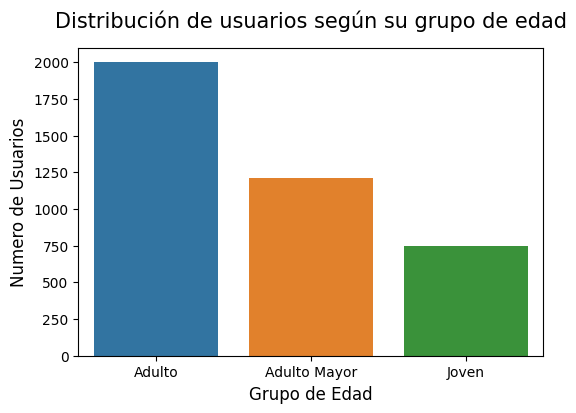

In [42]:
# Visualización de los segmentos por edad
plt.figure(figsize=(6,4))
sns.countplot(data=user_profile, x='grupo_edad')
plt.title('Distribución de usuarios según su grupo de edad', fontsize=15, pad=15)
plt.xlabel('Grupo de Edad', fontsize=12)
plt.ylabel('Numero de Usuarios', fontsize=12)
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?    
* **Dataset `users`:**
  * `city`: Presentaba valores centinela (`?`). Al reemplazarlos por valores nulos, representaron un **14.13%** de datos faltantes.
  * `churn_date`: Presenta un **88.4%** de nulos. Se conservaron intactos debido a que reflejan la lógica de negocio: representan a los **clientes activos que continúan con el servicio**.
  * `reg_date`: Presentaba inconsistencias con **fechas de registro futuras** (año 2026), las cuales se corrigieron convirtiendo la columna a formato fecha e imputando las anomalías como `pd.NaT`.

* **Dataset `usage`:**
  * `date`: Registró un **0.13%** de valores nulos, los cuales se ignoraron por su baja representatividad sobre el total de filas.
  * `duration` (**55.2%**) y `length` (**44.7%**): Se conservaron sin modificaciones por tratarse de **nulos estructurales** determinados por la variable `type`. Los mensajes de texto no generan minutos de llamada (`duration`) y las llamadas no generan longitud de caracteres (`length`).

- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?
* **Según el Nivel de Uso:**
  * **Uso medio:** Representa la gran mayoría de la base de usuarios (~2,900 usuarios).
  * **Bajo uso:** Es el segundo grupo en tamaño (~750 usuarios).
  * **Alto uso:** Constituye un grupo minoritario (~300 usuarios).

* **Según la Edad:**
  * **Adultos (30–59 años):** Conforman la mayor parte de la base de clientes (~2,000 usuarios).    
  * **Adultos Mayores (60+ años):** Representan una porción significativa (~1,200 usuarios).   
  * **Jóvenes (<30 años):** Muestran la menor participación (~750 usuarios).   
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?
    * **1. Grupo de "Uso Medio" :**
    * **Por qué es valioso:** Representa la aplastante mayoría de la base de clientes (~2,900 usuarios). Aunque individualmente no generan el consumo más alto, en conjunto constituyen la mayor fuente de ingresos recurrentes y estables para ConnectaTel. Garantizan la predictibilidad del flujo de caja.

    * **2. Grupo de "Alto Uso":**
    * **Por qué es valioso:** Aunque es un segmento reducido (~300 usuarios), representa a los clientes con mayor consumo por usuario.

    * **3. Segmento Demográfico "Adultos":**
    * **Por qué es valioso:** Constituye la franja demográfica principal (~2,000 usuarios). Estabilidad en el uso continuo del servicio frente a segmentos más jóvenes.
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?
* **Hallazgos de patrones extremos:**
  * **Consumo atípico de minutos:** Se identificó un subgrupo reducido de usuarios en el segmento de **"Alto uso"** cuyas duraciones de llamadas superan ampliamente el percentil 95 de la distribución normal del dataset.
  * **Sesgo hacia la derecha:** La distribución de la variable `duration` presenta un marcado sesgo positivo, donde la mayoría de las sesiones son cortas/medianas, pero un pequeño número de clientes acumula volúmenes de tráfico extraordinarios.

* **Implicaciones para el negocio:**
  * **Oportunidad de Up-selling:** Representan a los candidatos ideales para ser migrados proactivamente a planes ilimitados o paquetes empresariales/premium de mayor valor.
- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados


* **Creación de nuevos planes por segmento:**
  * **Plan "Voz & Mensajes Ilimitados" (Para usuarios de Alto Uso / Outliers):** Diseñar un plan de tarifa plana alta dirigido a los ~300 clientes de consumo extremo.
  * **Plan "Conecta Senior" (Para Adultos Mayores):** Crear un plan simplificado y económico, enfocado principalmente en voz/minutos para fidelizar al segmento de **Adulto Mayor** (~1,200 usuarios).
  * **Plan "Conecta Joven" (Captación de nuevos clientes):** Lanzar un paquete de entrada con tarifas atractivas en mensajes y llamadas cortas para atraer al grupo **Joven** ($<30$ años), que actualmente es el de menor penetración (~750 usuarios).



✍️ **Escribe aquí tu análisis ejecutivo:**

<details>
<summary><b>Análisis ejecutivo</b></summary>

<br>

#### ⚠️️ Problemas detectados en los datos

* **Dataset `users`:**
  * **Valores centinela en `city`:** La columna presentaba el carácter `?`. Al reemplazarlo por nulos, representó un **14.13%** de datos faltantes.
  * **Nulos de negocio en `churn_date`:** Un **88.4%** de la columna contenía nulos, los cuales representan a los **clientes activos que continúan con el servicio**.
  * **Anomalías temporales en `reg_date`:** Existían fechas de registro futuras (año 2026), corregidas convirtiendo a formato fecha e imputando las inconsistencias como `pd.NaT`.
* **Dataset `usage`:**
  * **Nulos menores en `date`:** Un **0.13%** de nulos que se descartaron por falta de representatividad.
  * **Nulos estructurales en `duration` (55.2%) y `length` (44.7%):** Se conservaron intactos porque obedecen a la variable `type` (los mensajes de texto no generan duración de llamadas y las llamadas no generan longitud de caracteres).

---

#### 🔍 Segmentos por Edad

* **Adultos (30–59 años):** Constituyen el núcleo principal con aproximadamente **2,000 usuarios**, representando la mayor estabilidad económica y menor morosidad.
* **Adultos Mayores (60+ años):** Representan una porción relevante con cerca de **1,200 usuarios**, requiriendo canales de atención accesibles y planes con foco en llamadas de voz.
* **Jóvenes (<30 años):** Representan el segmento menor con **~750 usuarios**, mostrando una oportunidad clara para campañas de adquisición orientadas a audiencias jóvenes.

---

#### 📊 Segmentos por Nivel de Uso

* **Uso medio:** Base principal del negocio con **~2,900 usuarios**, garantizando la mayor parte de los ingresos recurrentes y estables de ConnectaTel.
* **Bajo uso:** Segundo grupo más numeroso con **~750 usuarios**, con potencial para migrar a planes superiores mediante incentivos de reactivación.
* **Alto uso:** Grupo reducido con **~300 usuarios**, caracterizado por duraciones atípicas de llamadas y alto volumen de mensajes (outliers), con mayor riesgo de *churn* por cobros excesivos si no tienen tarifas planas.

---

➡️ **Esto sugiere que...**
La estrategia comercial de ConnectaTel no debe enfocarse únicamente en captar nuevos clientes, sino en **proteger la base central de Uso Medio** e implementar acciones defensivas en el segmento de **Alto Uso** para evitar la cancelación de líneas valiosas por sobrecostos. Además, la baja presencia del público joven señala la necesidad de reestructurar la oferta comercial para diversificar la audiencia.

---

#### 💡 Recomendaciones

* **Plan "Voz & Mensajes Ilimitados":** Diseñar una tarifa plana premium para los ~300 usuarios de **Alto uso**, eliminando penalizaciones por sobrecostos.
* **Plan "Conecta Senior":** Crear un paquete accesible y simplificado de voz/minutos dirigido al segmento de **Adultos Mayores** (~1,200 usuarios).
* **Plan "Conecta Joven":** Lanzar una oferta de entrada económica con tarifas atractivas en mensajes y llamadas cortas para captar la franja de menores de 30 años.
* **Upselling automatizado:** Implementar alertas de consumo para invitar a los clientes de **Bajo uso** a migrar a planes medios cuando su tráfico empiece a incrementarse.

</details>

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`